# UX25CS635A: Supervised Machine Learning – Classification
## Lab 1: Model Selection and Comparative Analysis — Dataset: Banknote Authentication

- **Name:** Mohamed Riaz
- **Registration Number:** PES1PGE25DS037
- **Department:** Data Science & AI

**Objective**: Build a complete ML pipeline (`StandardScaler -> SelectKBest -> Classifier`) for Decision Tree, kNN, and Logistic Regression, tune hyperparameters using (1) a manual Grid Search implemented from scratch and (2) scikit-learn's `GridSearchCV`, then compare the two implementations using Accuracy, Precision, Recall, F1, and ROC AUC.

## Part 1: Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import itertools
import warnings
import matplotlib.pyplot as plt
import ssl
from sklearn.base import clone
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay)

# Bypass SSL certificate verification for dataset downloads
ssl._create_default_https_context = ssl._create_unverified_context

# A feature can be constant within a single CV fold; f_classif then divides by a
# zero within-group variance for that fold, which is harmless but noisy, so silence it.
warnings.filterwarnings('ignore', message=".*Features.*are constant.*")
warnings.filterwarnings('ignore', message="invalid value encountered in divide")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Part 2: Dataset Loading — Banknote Authentication

Distinguishes genuine from forged banknotes using four features extracted from wavelet-transformed images (variance, skewness, curtosis, entropy).

In [2]:
def load_banknote():
    """Load Banknote Authentication dataset"""
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
    data = pd.read_csv(url, header=None)
    data.columns = ['variance', 'skewness', 'curtosis', 'entropy', 'class']

    # According to UCI: variance, skewness, curtosis, entropy, class (0=authentic, 1=fake)
    X = data.drop('class', axis=1)
    y = data['class']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.3, random_state=RANDOM_STATE
    )

    print("Banknote Authentication dataset loaded successfully.")
    print(f"Number of instances: {data.shape[0]}, Number of features: {X.shape[1]}")
    print(f"Training set shape: {X_train.shape}")
    print(f"Testing set shape: {X_test.shape}")
    print(f"Forged rate (train): {y_train.mean():.3f}")
    return X_train, X_test, y_train, y_test, "Banknote Authentication"

X_train, X_test, y_train, y_test, DATASET_NAME = load_banknote()

Banknote Authentication dataset loaded successfully.
Number of instances: 1372, Number of features: 4
Training set shape: (960, 4)
Testing set shape: (412, 4)
Forged rate (train): 0.445


## Part 3: Models and Parameter Grids

Parameter names are prefixed with the pipeline step name (`feature_selection__...`, `classifier__...`) so they can be applied directly to the `StandardScaler -> SelectKBest -> Classifier` pipeline. This dataset only has 4 features, so `k` is capped accordingly.

In [3]:
# Base models
dt_clf = DecisionTreeClassifier(random_state=RANDOM_STATE)
knn_clf = KNeighborsClassifier()
lr_clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)

param_grid_dt = {
    'feature_selection__k': [2, 3, 'all'],
    'classifier__max_depth': [3, 5, 10, None],
    'classifier__min_samples_split': [2, 5, 10]
}

param_grid_knn = {
    'feature_selection__k': [2, 3, 'all'],
    'classifier__n_neighbors': [3, 5, 7, 9],
    'classifier__weights': ['uniform', 'distance']
}

param_grid_lr = {
    'feature_selection__k': [2, 3, 'all'],
    'classifier__C': [0.01, 0.1, 1, 10]
}

# List of (classifier, param_grid, name) tuples
classifiers_to_tune = [
    (dt_clf, param_grid_dt, 'Decision Tree'),
    (knn_clf, param_grid_knn, 'kNN'),
    (lr_clf, param_grid_lr, 'Logistic Regression')
]

## Part 4: Manual Grid Search Implementation

In [4]:
def _adjust_k_grid(param_grid, n_features):
    """Ensure feature_selection__k values never exceed the number of available features."""
    adjusted = dict(param_grid)
    if 'feature_selection__k' in adjusted:
        valid_k = [k for k in adjusted['feature_selection__k'] if k == 'all' or k <= n_features]
        adjusted['feature_selection__k'] = valid_k if valid_k else ['all']
    return adjusted


def run_manual_grid_search(X_train, y_train, dataset_name):
    """Run manual grid search and return best estimators"""
    print(f"\n{'='*60}")
    print(f"RUNNING MANUAL GRID SEARCH FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    best_estimators = {}
    manual_cv_scores = {}
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    n_features = X_train.shape[1]

    for classifier_instance, param_grid, name in classifiers_to_tune:
        print(f"--- Manual Grid Search for {name} ---")
        best_score = -1
        best_params = None

        # 1. Adjust the feature selection grid so k never exceeds the number of features
        adjusted_grid = _adjust_k_grid(param_grid, n_features)

        # 2. Generate all combinations of hyperparameters
        keys = list(adjusted_grid.keys())
        value_lists = list(adjusted_grid.values())
        all_combinations = list(itertools.product(*value_lists))

        for combo in all_combinations:
            params = dict(zip(keys, combo))
            fold_aucs = []

            # 3a. 5-fold stratified cross-validation
            for train_idx, val_idx in cv.split(X_train, y_train):
                X_fold_train = X_train.iloc[train_idx]
                X_fold_val = X_train.iloc[val_idx]
                y_fold_train = y_train.iloc[train_idx]
                y_fold_val = y_train.iloc[val_idx]

                pipeline = Pipeline(steps=[
                    ('scaler', StandardScaler()),
                    ('feature_selection', SelectKBest(f_classif)),
                    ('classifier', clone(classifier_instance))
                ])
                pipeline.set_params(**params)
                pipeline.fit(X_fold_train, y_fold_train)

                y_val_proba = pipeline.predict_proba(X_fold_val)[:, 1]
                fold_aucs.append(roc_auc_score(y_fold_val, y_val_proba))

            mean_auc = np.mean(fold_aucs)
            if mean_auc > best_score:
                best_score = mean_auc
                best_params = params

        print("-" * 90)
        print(f"Best parameters for {name}: {best_params}")
        print(f"Best cross-validation AUC: {best_score:.4f}")

        # Create the final pipeline for this classifier
        final_pipeline = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('feature_selection', SelectKBest(f_classif)),
            ('classifier', clone(classifier_instance))
        ])

        # Set the best parameters found
        final_pipeline.set_params(**best_params)

        # Fit the final pipeline on the full training data
        final_pipeline.fit(X_train, y_train)

        # Store the fully trained best pipeline
        best_estimators[name] = final_pipeline
        manual_cv_scores[name] = {'best_params': best_params, 'best_score (CV)': best_score}

    return best_estimators, manual_cv_scores


manual_estimators, manual_cv_scores = run_manual_grid_search(X_train, y_train, DATASET_NAME)


RUNNING MANUAL GRID SEARCH FOR BANKNOTE AUTHENTICATION
--- Manual Grid Search for Decision Tree ---


------------------------------------------------------------------------------------------
Best parameters for Decision Tree: {'feature_selection__k': 3, 'classifier__max_depth': 10, 'classifier__min_samples_split': 10}
Best cross-validation AUC: 0.9869
--- Manual Grid Search for kNN ---


------------------------------------------------------------------------------------------
Best parameters for kNN: {'feature_selection__k': 3, 'classifier__n_neighbors': 5, 'classifier__weights': 'distance'}
Best cross-validation AUC: 1.0000
--- Manual Grid Search for Logistic Regression ---


------------------------------------------------------------------------------------------
Best parameters for Logistic Regression: {'feature_selection__k': 3, 'classifier__C': 10}
Best cross-validation AUC: 0.9995


## Part 5: Built-in `GridSearchCV` Implementation

In [5]:
def run_builtin_grid_search(X_train, y_train, dataset_name):
    """Run built-in grid search and return best estimators"""
    print(f"\n{'='*60}")
    print(f"RUNNING BUILT-IN GRID SEARCH FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    results_builtin = {}
    n_features = X_train.shape[1]

    for classifier_instance, param_grid, name in classifiers_to_tune:
        print(f"\n--- GridSearchCV for {name} ---")

        adjusted_grid = _adjust_k_grid(param_grid, n_features)

        pipeline = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('feature_selection', SelectKBest(f_classif)),
            ('classifier', clone(classifier_instance))
        ])
        cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=adjusted_grid,
            scoring='roc_auc',
            cv=cv_splitter,
            n_jobs=-1
        )
        grid_search.fit(X_train, y_train)

        results_builtin[name] = {
            'best_estimator': grid_search.best_estimator_,
            'best_score (CV)': grid_search.best_score_,
            'best_params': grid_search.best_params_
        }
        print(f"Best params for {name}: {results_builtin[name]['best_params']}")
        print(f"Best CV score: {results_builtin[name]['best_score (CV)']:.4f}")

    return results_builtin


builtin_results = run_builtin_grid_search(X_train, y_train, DATASET_NAME)
builtin_estimators = {name: res['best_estimator'] for name, res in builtin_results.items()}


RUNNING BUILT-IN GRID SEARCH FOR BANKNOTE AUTHENTICATION

--- GridSearchCV for Decision Tree ---


Best params for Decision Tree: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'feature_selection__k': 3}
Best CV score: 0.9869

--- GridSearchCV for kNN ---
Best params for kNN: {'classifier__n_neighbors': 5, 'classifier__weights': 'distance', 'feature_selection__k': 3}
Best CV score: 1.0000

--- GridSearchCV for Logistic Regression ---


Best params for Logistic Regression: {'classifier__C': 10, 'feature_selection__k': 3}
Best CV score: 0.9995


## Part 6: Model Evaluation and Voting Classifiers

In [6]:
def evaluate_models(X_train, y_train, X_test, y_test, best_estimators, dataset_name, method_name="Manual"):
    """Evaluate models and create visualizations. Returns a metrics dataframe."""
    print(f"\n{'='*60}")
    print(f"EVALUATING {method_name.upper()} MODELS FOR {dataset_name.upper()}")
    print(f"{'='*60}")

    rows = []

    print("\n--- Individual Model Performance ---")
    for name, model in best_estimators.items():
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        auc = roc_auc_score(y_test, y_pred_proba)
        print(f"\n{name}:")
        print(f"  Accuracy: {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall: {rec:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"  ROC AUC: {auc:.4f}")
        rows.append({'Method': method_name, 'Model': name, 'Accuracy': acc, 'Precision': prec,
                      'Recall': rec, 'F1-Score': f1, 'ROC AUC': auc})

    print(f"\n--- {method_name} Voting Classifier ---")

    if method_name == "Manual":
        y_pred_votes = []
        y_pred_proba_avg = []
        for i in range(len(X_test)):
            votes, probas = [], []
            for name, model in best_estimators.items():
                pred = model.predict(X_test.iloc[[i]])[0]
                proba = model.predict_proba(X_test.iloc[[i]])[0, 1]
                votes.append(pred)
                probas.append(proba)
            y_pred_votes.append(1 if np.mean(votes) > 0.5 else 0)
            y_pred_proba_avg.append(np.mean(probas))
        y_pred_votes = np.array(y_pred_votes)
        y_pred_proba_avg = np.array(y_pred_proba_avg)
    else:
        estimators = [(name, model) for name, model in best_estimators.items()]
        voting_clf = VotingClassifier(estimators=estimators, voting='soft')
        voting_clf.fit(X_train, y_train)
        y_pred_votes = voting_clf.predict(X_test)
        y_pred_proba_avg = voting_clf.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred_votes)
    precision = precision_score(y_test, y_pred_votes, zero_division=0)
    recall = recall_score(y_test, y_pred_votes, zero_division=0)
    f1 = f1_score(y_test, y_pred_votes, zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba_avg)

    print("Voting Classifier Performance:")
    print(f"  Accuracy: {accuracy:.4f}, Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
    rows.append({'Method': method_name, 'Model': 'Voting Classifier', 'Accuracy': accuracy,
                  'Precision': precision, 'Recall': recall, 'F1-Score': f1, 'ROC AUC': auc})

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    for name, model in best_estimators.items():
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc_score = roc_auc_score(y_test, y_pred_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')
    fpr_vote, tpr_vote, _ = roc_curve(y_test, y_pred_proba_avg)
    plt.plot(fpr_vote, tpr_vote, label=f'Voting (AUC = {auc:.3f})', linewidth=3, linestyle='--')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - {dataset_name} ({method_name})')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    cm = confusion_matrix(y_test, y_pred_votes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=plt.gca(), cmap="Blues")
    plt.title(f'Voting Classifier - {dataset_name} ({method_name})')

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(rows), y_pred_votes, y_pred_proba_avg


EVALUATING MANUAL MODELS FOR BANKNOTE AUTHENTICATION

--- Individual Model Performance ---

Decision Tree:
  Accuracy: 0.9854
  Precision: 0.9784
  Recall: 0.9891
  F1-Score: 0.9837
  ROC AUC: 0.9856

kNN:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC AUC: 1.0000

Logistic Regression:
  Accuracy: 0.9903
  Precision: 0.9786
  Recall: 1.0000
  F1-Score: 0.9892
  ROC AUC: 0.9999

--- Manual Voting Classifier ---


Voting Classifier Performance:
  Accuracy: 1.0000, Precision: 1.0000
  Recall: 1.0000, F1: 1.0000, AUC: 1.0000


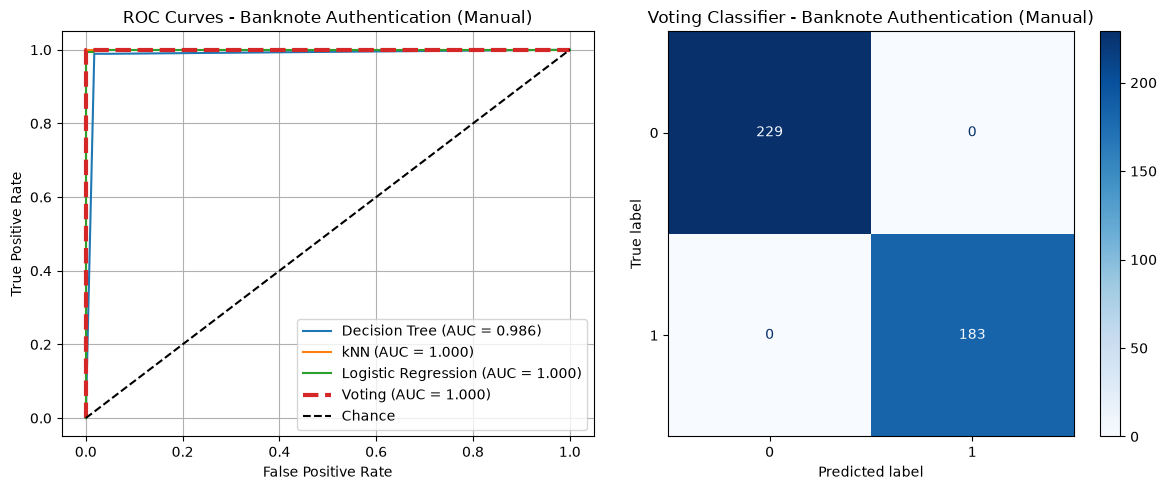

In [7]:
manual_metrics_df, manual_votes, manual_proba = evaluate_models(
    X_train, y_train, X_test, y_test, manual_estimators, DATASET_NAME, "Manual"
)


EVALUATING BUILT-IN MODELS FOR BANKNOTE AUTHENTICATION

--- Individual Model Performance ---

Decision Tree:
  Accuracy: 0.9854
  Precision: 0.9784
  Recall: 0.9891
  F1-Score: 0.9837
  ROC AUC: 0.9856

kNN:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-Score: 1.0000
  ROC AUC: 1.0000

Logistic Regression:
  Accuracy: 0.9903
  Precision: 0.9786
  Recall: 1.0000
  F1-Score: 0.9892
  ROC AUC: 0.9999

--- Built-in Voting Classifier ---
Voting Classifier Performance:
  Accuracy: 1.0000, Precision: 1.0000
  Recall: 1.0000, F1: 1.0000, AUC: 1.0000


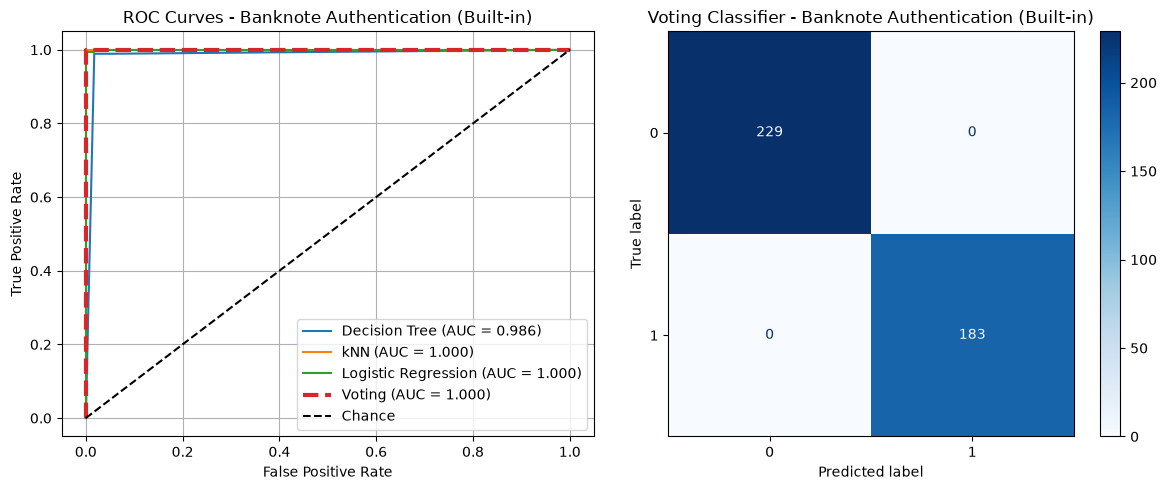

In [8]:
builtin_metrics_df, builtin_votes, builtin_proba = evaluate_models(
    X_train, y_train, X_test, y_test, builtin_estimators, DATASET_NAME, "Built-in"
)

## Part 7: Manual vs. Built-in Comparison

In [9]:
comparison_df = pd.concat([manual_metrics_df, builtin_metrics_df], ignore_index=True)
comparison_df = comparison_df.sort_values(['Model', 'Method']).reset_index(drop=True)
comparison_df

,Method,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC
0,Built-in,Decision Tree,0.985437,0.978378,0.989071,0.983696,0.985611
1,Manual,Decision Tree,0.985437,0.978378,0.989071,0.983696,0.985611
2,Built-in,Logistic Regression,0.990291,0.978610,1.000000,0.989189,0.999905
3,Manual,Logistic Regression,0.990291,0.978610,1.000000,0.989189,0.999905
4,Built-in,Voting Classifier,1.000000,1.000000,1.000000,1.000000,1.000000
5,Manual,Voting Classifier,1.000000,1.000000,1.000000,1.000000,1.000000
6,Built-in,kNN,1.000000,1.000000,1.000000,1.000000,1.000000
7,Manual,kNN,1.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
print("Manual best params/CV AUC:")
for name, res in manual_cv_scores.items():
    print(f"  {name}: {res['best_params']} -> CV AUC {res['best_score (CV)']:.4f}")

print("\nBuilt-in best params/CV AUC:")
for name, res in builtin_results.items():
    print(f"  {name}: {res['best_params']} -> CV AUC {res['best_score (CV)']:.4f}")

best_row = comparison_df.loc[comparison_df['ROC AUC'].idxmax()]
print(f"\nBest overall model for {DATASET_NAME}: {best_row['Model']} ({best_row['Method']}) "
      f"with test ROC AUC = {best_row['ROC AUC']:.4f}")

Manual best params/CV AUC:
  Decision Tree: {'feature_selection__k': 3, 'classifier__max_depth': 10, 'classifier__min_samples_split': 10} -> CV AUC 0.9869
  kNN: {'feature_selection__k': 3, 'classifier__n_neighbors': 5, 'classifier__weights': 'distance'} -> CV AUC 1.0000
  Logistic Regression: {'feature_selection__k': 3, 'classifier__C': 10} -> CV AUC 0.9995

Built-in best params/CV AUC:
  Decision Tree: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'feature_selection__k': 3} -> CV AUC 0.9869
  kNN: {'classifier__n_neighbors': 5, 'classifier__weights': 'distance', 'feature_selection__k': 3} -> CV AUC 1.0000
  Logistic Regression: {'classifier__C': 10, 'feature_selection__k': 3} -> CV AUC 0.9995

Best overall model for Banknote Authentication: Voting Classifier (Built-in) with test ROC AUC = 1.0000
